# Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import rasterio

from sklearn.metrics import confusion_matrix, classification_report

print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
Using device: cuda


# Config and Class Names

In [2]:
MS_VAL  = "EuroSATallBands/val"
MS_TEST = "EuroSATallBands_test_flat"

CLASSES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES  = 10

# sentinel-2 band names in order, for labeling plots
BAND_NAMES = ["B1", "B2", "B3", "B4", "B5", "B6", "B7",
              "B8", "B8A", "B9", "B10", "B11", "B12"]

# Model architecture


In [3]:
class SpectralAttention(nn.Module):
    def __init__(self, num_bands, reduction=4):
        super().__init__()
        self.excitation = nn.Sequential(
            nn.Linear(num_bands, num_bands // reduction),
            nn.ReLU(),
            nn.Linear(num_bands // reduction, num_bands),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = x.mean(dim=[2, 3])
        weights = self.excitation(weights)
        weights = weights.unsqueeze(-1).unsqueeze(-1)
        return x * weights, weights.squeeze()


class AttentionCNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super().__init__()
        self.attention = SpectralAttention(in_channels)
        self.features  = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),           nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),          nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),         nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x, return_weights=False):
        x, weights = self.attention(x)
        out = self.classifier(self.features(x))
        if return_weights:
            return out, weights
        return out

# load saved weights
model = AttentionCNN(in_channels=13).to(device)
model.load_state_dict(torch.load("attn_ms_best.pt", map_location=device))
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [4]:
model.eval()

AttentionCNN(
  (attention): SpectralAttention(
    (excitation): Sequential(
      (0): Linear(in_features=13, out_features=3, bias=True)
      (1): ReLU()
      (2): Linear(in_features=3, out_features=13, bias=True)
      (3): Sigmoid()
    )
  )
  (features): Sequential(
    (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxP

# Validation dataset and loader

In [5]:
class MSDataset(Dataset):
    def __init__(self, root, augment=False):
        self.samples = []
        self.augment = augment
        for cls in CLASSES:
            folder = os.path.join(root, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(".tif"):
                    self.samples.append((os.path.join(folder, fname), CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)
        img = np.clip(img / 10000.0, 0, 1)
        return torch.tensor(img), label, path  # also return path for later

ms_val_ds     = MSDataset(MS_VAL)
ms_val_loader = DataLoader(ms_val_ds, batch_size=32, shuffle=False, num_workers=0)
print("Val samples:", len(ms_val_ds))

Val samples: 4050


# Collecting all predictions and attention weights on val set

In [6]:
all_preds   = []
all_labels  = []
all_weights = []  # attention weights, shape (N, 13)
all_paths   = []

with torch.no_grad():
    for x, y, paths in ms_val_loader:
        x = x.to(device)
        out, weights = model(x, return_weights=True)
        preds = out.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y)
        all_weights.append(weights.cpu())
        all_paths.extend(paths)

all_preds   = torch.cat(all_preds).numpy()
all_labels  = torch.cat(all_labels).numpy()
all_weights = torch.cat(all_weights).numpy()  # (N, 13)

print("Collected predictions for", len(all_preds), "samples")
print("Overall val accuracy:", (all_preds == all_labels).mean())

Collected predictions for 4050 samples
Overall val accuracy: 0.9839506172839506


# confusion matrix

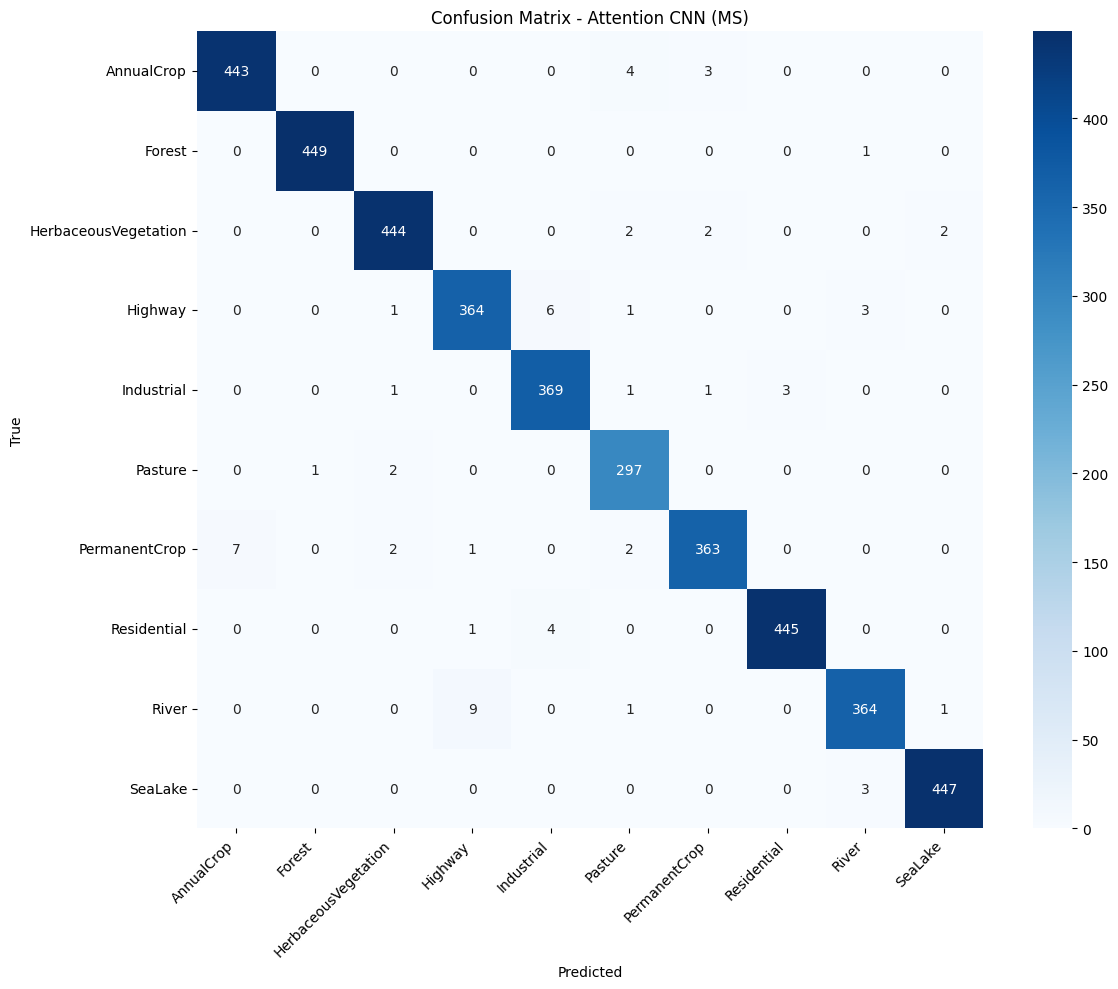

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       450
              Forest       1.00      1.00      1.00       450
HerbaceousVegetation       0.99      0.99      0.99       450
             Highway       0.97      0.97      0.97       375
          Industrial       0.97      0.98      0.98       375
             Pasture       0.96      0.99      0.98       300
       PermanentCrop       0.98      0.97      0.98       375
         Residential       0.99      0.99      0.99       450
               River       0.98      0.97      0.98       375
             SeaLake       0.99      0.99      0.99       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050



In [7]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Attention CNN (MS)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Most confused pair classes:

In [8]:
# zero out diagonal (correct predictions) and find top confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# get top 5 confused pairs
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((cm_no_diag[i, j], CLASSES[i], CLASSES[j]))

confused_pairs.sort(reverse=True)
print("Top confused class pairs (true -> predicted):")
for count, true_cls, pred_cls in confused_pairs[:8]:
    print(f"  {true_cls} -> {pred_cls}: {count} samples")

Top confused class pairs (true -> predicted):
  River -> Highway: 9 samples
  PermanentCrop -> AnnualCrop: 7 samples
  Highway -> Industrial: 6 samples
  Residential -> Industrial: 4 samples
  AnnualCrop -> Pasture: 4 samples
  SeaLake -> River: 3 samples
  Industrial -> Residential: 3 samples
  Highway -> River: 3 samples


# Band importance per class

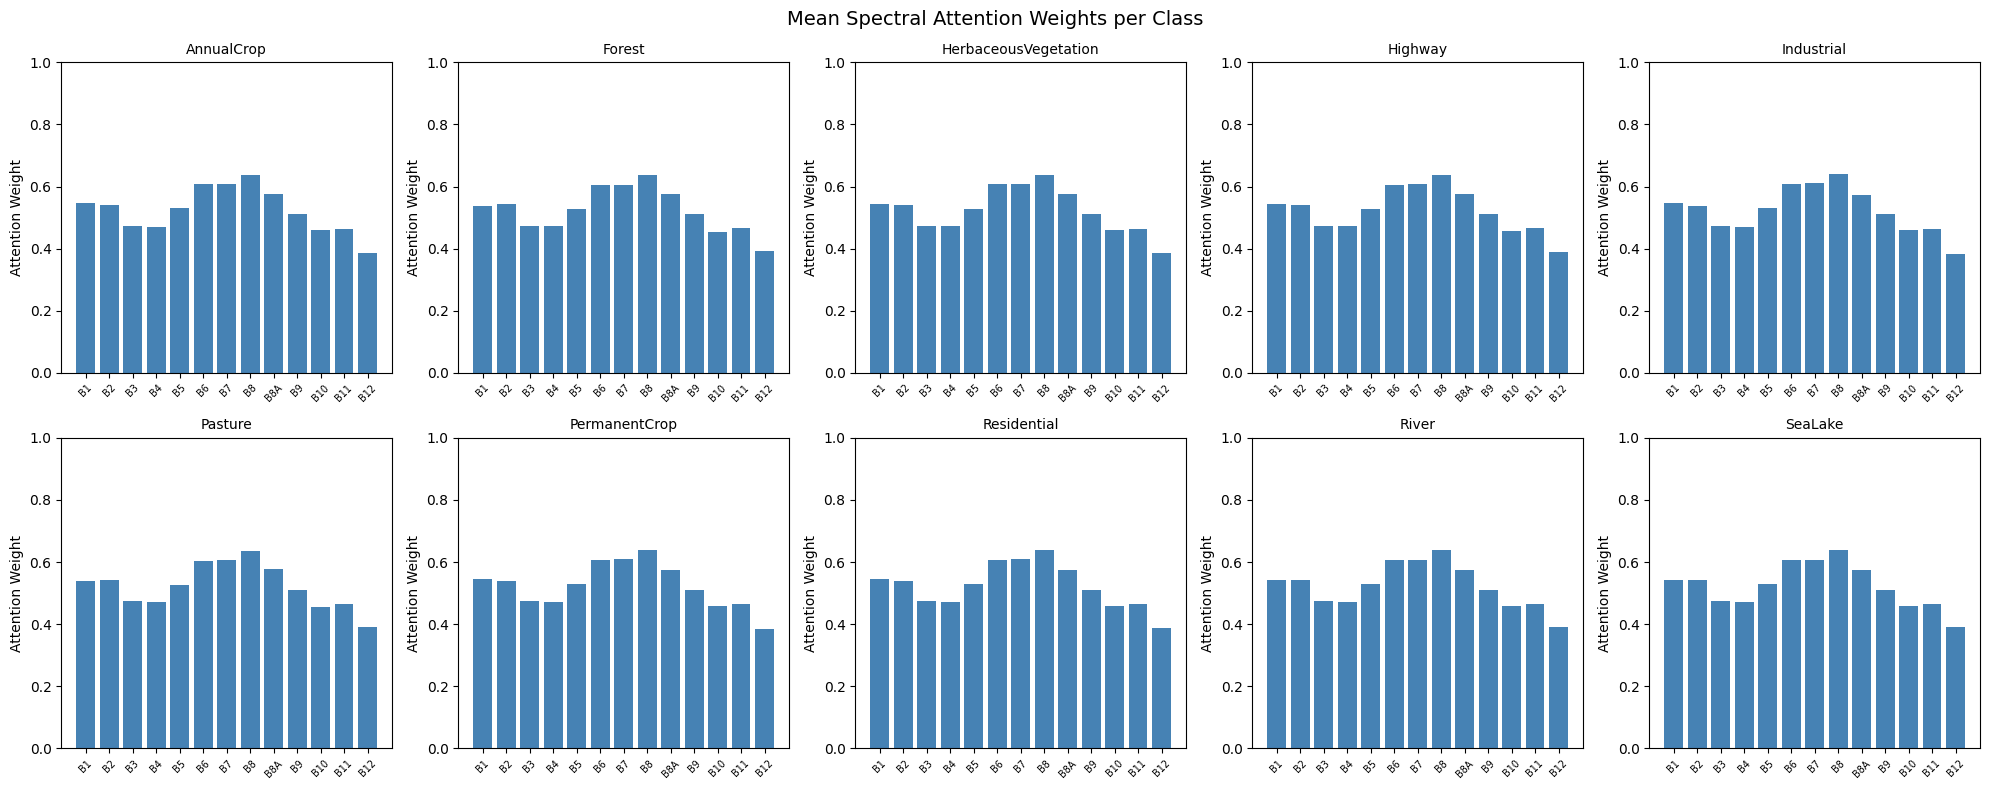

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for cls_idx, cls_name in enumerate(CLASSES):
    mask = all_labels == cls_idx
    mean_weights = all_weights[mask].mean(axis=0)  # avg over all samples of this class

    axes[cls_idx].bar(BAND_NAMES, mean_weights, color="steelblue")
    axes[cls_idx].set_title(cls_name, fontsize=10)
    axes[cls_idx].set_ylim(0, 1)
    axes[cls_idx].tick_params(axis="x", rotation=45, labelsize=7)
    axes[cls_idx].set_ylabel("Attention Weight")

plt.suptitle("Mean Spectral Attention Weights per Class", fontsize=14)
plt.tight_layout()
plt.savefig("band_importance_per_class.png", dpi=150)
plt.show()

# Overall band importance across all classes

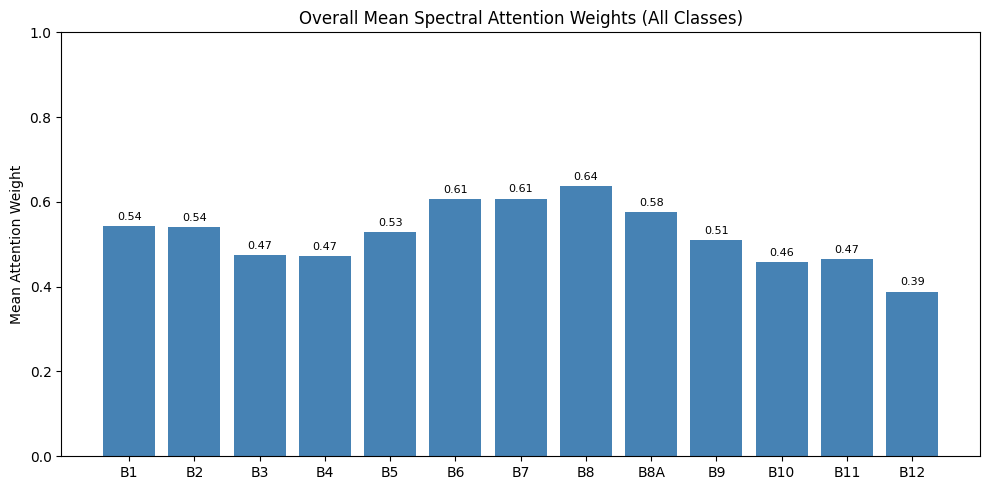

In [10]:
overall_mean = all_weights.mean(axis=0)  # avg over all samples

plt.figure(figsize=(10, 5))
bars = plt.bar(BAND_NAMES, overall_mean, color="steelblue")
plt.title("Overall Mean Spectral Attention Weights (All Classes)")
plt.ylabel("Mean Attention Weight")
plt.ylim(0, 1)

# annotate values on bars
for bar, val in zip(bars, overall_mean):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("overall_band_importance.png", dpi=150)
plt.show()

# NDVI and NDWI
NDVI uses B8 (NIR) and B4 (Red). NDWI uses B3 (Green) and B8 (NIR). We compute these per sample and show their distribution per class. This connects the band weights to established indices.

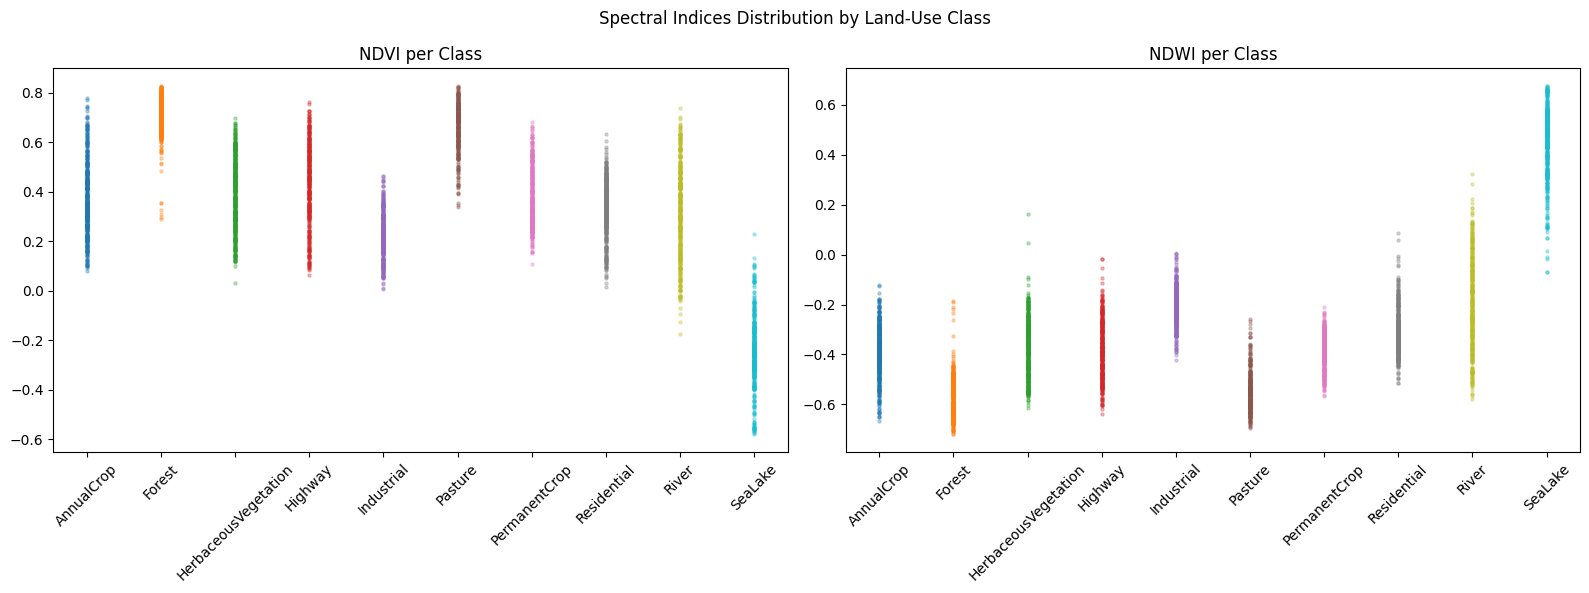

In [11]:
# band indices in the 13-band stack
# B1=0, B2=1, B3=2, B4=3, B5=4, B6=5, B7=6, B8=7, B8A=8, B9=9, B10=10, B11=11, B12=12

def compute_indices(path):
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32) / 10000.0
    NIR   = img[7]   # B8
    Red   = img[3]   # B4
    Green = img[2]   # B3
    SWIR  = img[11]  # B11

    ndvi = (NIR - Red)   / (NIR + Red   + 1e-6)
    ndwi = (Green - NIR) / (Green + NIR + 1e-6)
    return ndvi.mean(), ndwi.mean()

# compute for all val samples (takes a minute)
ndvi_vals, ndwi_vals, index_labels = [], [], []
for path, label in zip(all_paths, all_labels):
    ndvi, ndwi = compute_indices(path)
    ndvi_vals.append(ndvi)
    ndwi_vals.append(ndwi)
    index_labels.append(label)

ndvi_vals    = np.array(ndvi_vals)
ndwi_vals    = np.array(ndwi_vals)
index_labels = np.array(index_labels)

# plot NDVI distribution per class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cls_idx, cls_name in enumerate(CLASSES):
    mask = index_labels == cls_idx
    axes[0].scatter([cls_name] * mask.sum(), ndvi_vals[mask], alpha=0.3, s=5)
    axes[1].scatter([cls_name] * mask.sum(), ndwi_vals[mask], alpha=0.3, s=5)

axes[0].set_title("NDVI per Class"); axes[0].tick_params(axis="x", rotation=45)
axes[1].set_title("NDWI per Class"); axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Spectral Indices Distribution by Land-Use Class")
plt.tight_layout()
plt.savefig("ndvi_ndwi_per_class.png", dpi=150)
plt.show()

# Grad-CAM implementation
Grad-CAM hooks into the last conv layer and uses gradients to produce a spatial heatmap showing where the model focused.

In [12]:
class GradCAM:
    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None

        # hook onto the last conv layer (index 12 in features = last Conv2d before classifier)
        target_layer = model.features[12]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        x = x.unsqueeze(0).to(device)  # add batch dim
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        self.model.zero_grad()
        out[0, class_idx].backward()

        # pool gradients over spatial dims
        weights     = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam         = (weights * self.activations).sum(dim=1).squeeze()  # (H, W)
        cam         = F.relu(cam)
        cam         = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), class_idx

gradcam = GradCAM(model)
print("GradCAM ready")

GradCAM ready


# Visualizing Grad-CAM on correct predictions
We pick one correct example per class and show the RGB view alongside the heatmap.

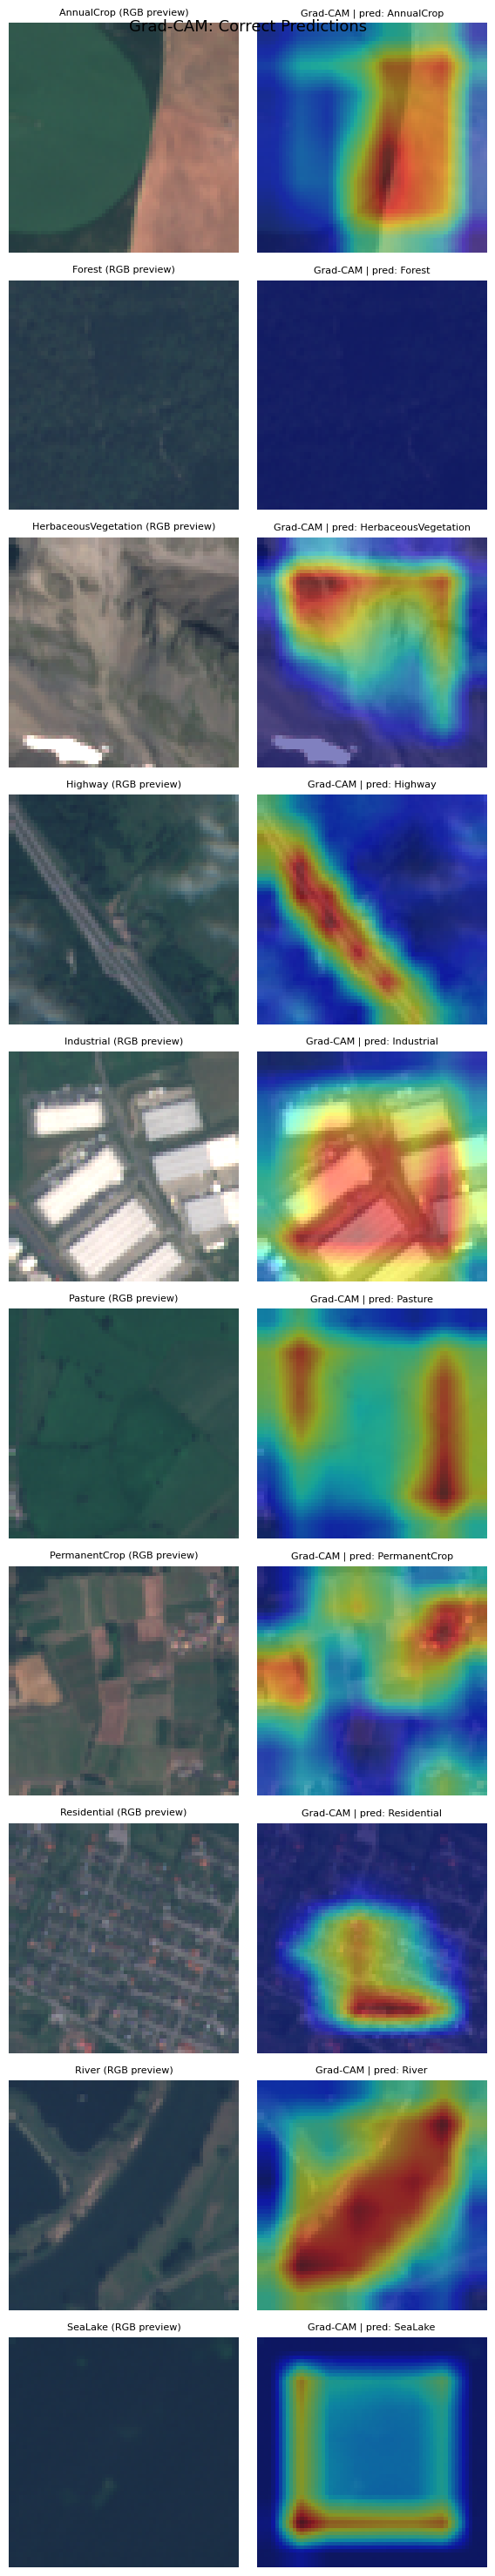

In [13]:
def load_rgb_preview(path):
    # read bands 4,3,2 (Red, Green, Blue) from tif for display
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
    rgb = np.stack([img[3], img[2], img[1]], axis=-1)  # (64, 64, 3)
    rgb = np.clip(rgb / 3000.0, 0, 1)  # stretch for visibility
    return rgb


fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(6, NUM_CLASSES * 3))

for cls_idx, cls_name in enumerate(CLASSES):
    # find first correct prediction for this class
    mask    = (all_labels == cls_idx) & (all_preds == cls_idx)
    indices = np.where(mask)[0]
    if len(indices) == 0:
        continue
    sample_idx = indices[0]
    path       = all_paths[sample_idx]

    with rasterio.open(path) as src:
        img = torch.tensor(src.read().astype(np.float32) / 10000.0)

    cam, pred_idx = gradcam.generate(img)
    rgb_preview   = load_rgb_preview(path)

    # upsample cam to 64x64
    cam_resized = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=(64, 64), mode="bilinear", align_corners=False
    ).squeeze().numpy()

    axes[cls_idx, 0].imshow(rgb_preview)
    axes[cls_idx, 0].set_title(f"{cls_name} (RGB preview)", fontsize=8)
    axes[cls_idx, 0].axis("off")

    axes[cls_idx, 1].imshow(rgb_preview)
    axes[cls_idx, 1].imshow(cam_resized, cmap="jet", alpha=0.5)
    axes[cls_idx, 1].set_title(f"Grad-CAM | pred: {CLASSES[pred_idx]}", fontsize=8)
    axes[cls_idx, 1].axis("off")

plt.suptitle("Grad-CAM: Correct Predictions", fontsize=13)
plt.tight_layout()
plt.savefig("gradcam_correct.png", dpi=150)
plt.show()

# Grad-CAM on incorrect predictions
Same thing but for wrong predictions — picked the most confused pair from Cell 7.

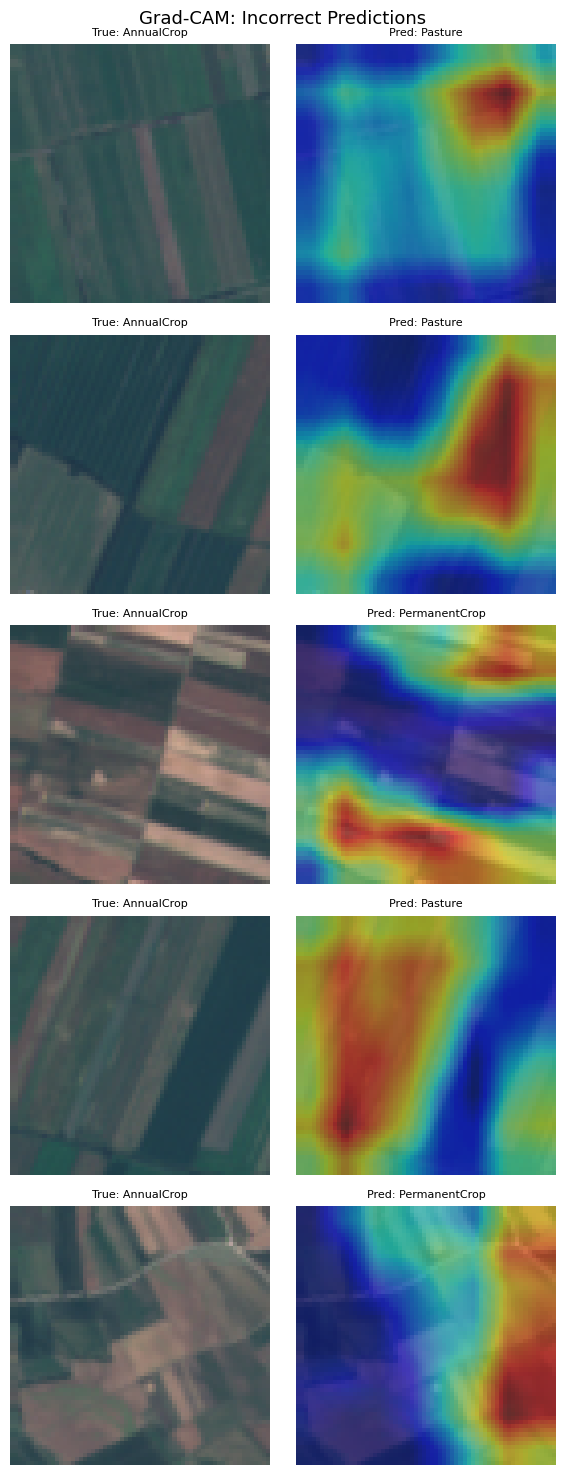

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(6, 15))

# get 5 misclassified samples
wrong_indices = np.where(all_preds != all_labels)[0][:5]

for row, sample_idx in enumerate(wrong_indices):
    path      = all_paths[sample_idx]
    true_cls  = CLASSES[all_labels[sample_idx]]
    pred_cls  = CLASSES[all_preds[sample_idx]]

    with rasterio.open(path) as src:
        img = torch.tensor(src.read().astype(np.float32) / 10000.0)

    cam, _ = gradcam.generate(img, class_idx=all_preds[sample_idx])
    cam_resized = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=(64, 64), mode="bilinear", align_corners=False
    ).squeeze().numpy()

    rgb_preview = load_rgb_preview(path)

    axes[row, 0].imshow(rgb_preview)
    axes[row, 0].set_title(f"True: {true_cls}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(rgb_preview)
    axes[row, 1].imshow(cam_resized, cmap="jet", alpha=0.5)
    axes[row, 1].set_title(f"Pred: {pred_cls}", fontsize=8)
    axes[row, 1].axis("off")

plt.suptitle("Grad-CAM: Incorrect Predictions", fontsize=13)
plt.tight_layout()
plt.savefig("gradcam_incorrect.png", dpi=150)
plt.show()

# Generating MS test predictions CSV


In [15]:
class MSTestDataset(Dataset):
    def __init__(self, root):
        self.samples = []
        for fname in os.listdir(root):
            if fname.lower().endswith(".tif"):
                self.samples.append((os.path.join(root, fname), fname))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, fname = self.samples[idx]
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)
        img = np.clip(img / 10000.0, 0, 1)
        return torch.tensor(img), fname

ms_test_ds     = MSTestDataset(MS_TEST)
ms_test_loader = DataLoader(ms_test_ds, batch_size=32, shuffle=False, num_workers=0)
print("Test samples:", len(ms_test_ds))

Test samples: 4050


In [16]:
img_ids, pred_labels = [], []

model.eval()
with torch.no_grad():
    for x, fnames in ms_test_loader:
        x    = x.to(device)
        out  = model(x)
        preds = out.argmax(dim=1).cpu().numpy()
        for fname, pred in zip(fnames, preds):
            img_ids.append(fname)
            pred_labels.append(pred)

ms_df = pd.DataFrame({"img_id": img_ids, "predicted_label": pred_labels})
ms_df.to_csv("ms_predictions.csv", index=False)
print("Saved ms_predictions.csv")
print(ms_df.head(10))
print("Label distribution:")
print(ms_df["predicted_label"].value_counts().sort_index())

Saved ms_predictions.csv
          img_id  predicted_label
0     test_1.tif                0
1    test_10.tif                0
2   test_100.tif                0
3  test_1000.tif                2
4  test_1001.tif                2
5  test_1002.tif                2
6  test_1003.tif                2
7  test_1004.tif                2
8  test_1005.tif                2
9  test_1006.tif                2
Label distribution:
predicted_label
0    457
1    450
2    447
3    376
4    378
5    303
6    369
7    450
8    370
9    450
Name: count, dtype: int64
